<a href="https://colab.research.google.com/github/Lochan9866/Machine_Learning_Projects/blob/main/Bike_Sharing_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import warnings
warnings.filterwarnings('ignore')

## 1. Data Understanding and Exploration ##

In [66]:
# Importing libraries
import pandas as pd
import numpy as np

In [67]:
# Reading the dataset
dataset = pd.read_csv("bike_sharing_data.csv")

In [68]:
dataset

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


In [69]:
dataset.shape

(730, 16)

In [70]:
dataset.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [71]:
dataset.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [72]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [73]:
## Assigning string values to different seasons instead of numeric values

#1 = spring
dataset.loc[(dataset['season'] == 1), 'season'] = 'spring'

#2 = Summer
dataset.loc[(dataset['season'] == 2), 'season'] = 'summer'

#3 = Fall
dataset.loc[(dataset['season'] == 3), 'season'] = 'fall'

#4 = winter
dataset.loc[(dataset['season'] == 4), 'season'] = 'winter'

In [74]:
dataset['season'].astype('category').value_counts()

,count
season,
fall,188
summer,184
spring,180
winter,178


In [75]:
# 0 = 2018, 1= 2019 : Year
dataset['yr'].astype('category').value_counts()

,count
yr,
0,365
1,365


In [76]:
# Assigning string values to different months instead of numeric values
def object_map_mnths(x):
  return x.map({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})

In [77]:
dataset[['mnth']]=dataset[['mnth']].apply(object_map_mnths)

In [78]:
dataset['mnth'].astype('category').value_counts()

,count
mnth,
Aug,62
Dec,62
Jul,62
Jan,62
Oct,62
May,62
Mar,62
Apr,60
Nov,60


In [79]:
dataset['holiday'].astype('category').value_counts()

,count
holiday,
0,709
1,21


In [80]:
def str_map_weekday(x):
  return x.map({0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'})

In [81]:
dataset[['weekday']]=dataset[['weekday']].apply(str_map_weekday)

In [82]:
dataset['weekday'].astype('category').value_counts()

,count
weekday,
Mon,105
Sat,105
Sun,105
Fri,104
Thu,104
Tue,104
Wed,103


In [83]:
dataset['workingday'].astype('category').value_counts()

,count
workingday,
1,499
0,231


In [84]:
# 1 = Clear. few clouds, Partly Cloudly
dataset.loc[(dataset['weathersit'] == 1), 'weathersit'] = 'A'

#2 = Mist, Cloudly
dataset.loc[(dataset['weathersit'] == 2), 'weathersit'] = 'B'

#3 = Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain
dataset.loc[(dataset['weathersit'] == 3), 'weathersit'] = 'C'

#4 = Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
dataset.loc[(dataset['weathersit'] == 4), 'weathersit'] = 'D'

In [85]:
dataset['weathersit'].astype('category').value_counts()

,count
weathersit,
A,463
B,246
C,21


## 2. Data Visualisation ##

In [86]:
# Importing Libs
import matplotlib.pyplot as plt
import seaborn as sns

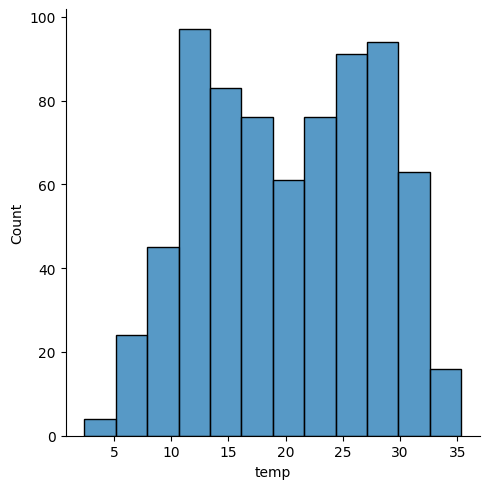

In [87]:
# Temperature
sns.displot(dataset['temp'])
plt.show()

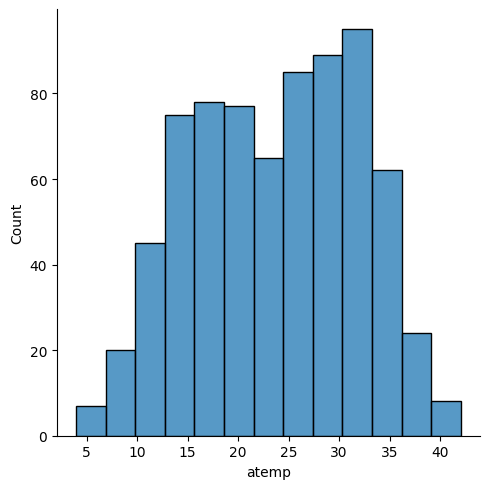

In [88]:
# Actual Temperature
sns.displot(dataset['atemp'])
plt.show()

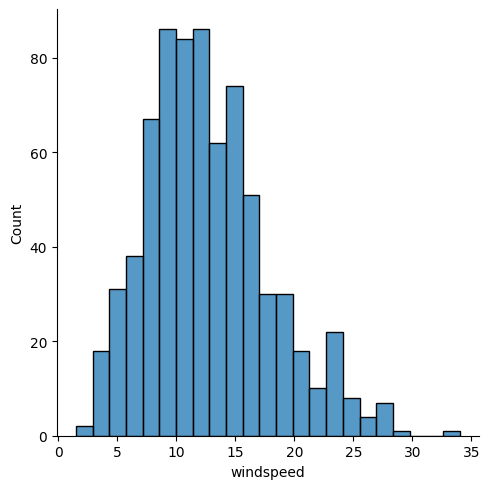

In [89]:
# Wind Speed
sns.displot(dataset['windspeed'])
plt.show()

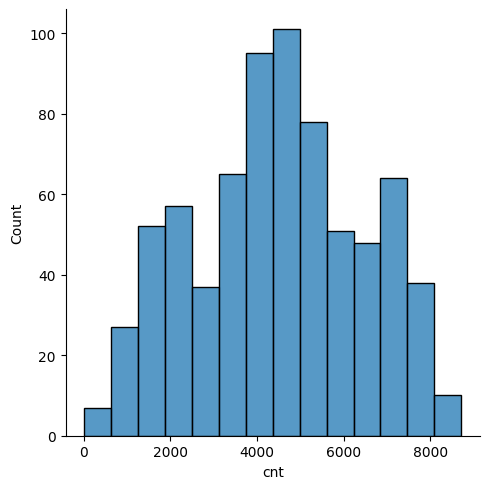

In [90]:
# Target variable: Count of total rental bikes including both casual and registered
sns.displot(dataset['cnt'])
plt.show()

In [91]:
# Converting date to datetime format
dataset['dteday'] = dataset['dteday'].astype('datetime64[ns]')

In [92]:
dataset_categorical = dataset.select_dtypes(exclude=['float64', 'datetime64[ns]','int64'])

In [93]:
dataset_categorical.columns

Index(['season', 'mnth', 'weekday', 'weathersit'], dtype='object')

In [94]:
dataset_categorical

,season,mnth,weekday,weathersit
0,spring,Jan,Sat,B
1,spring,Jan,Sun,B
2,spring,Jan,Mon,A
3,spring,Jan,Tue,A
4,spring,Jan,Wed,A
...,...,...,...,...
725,spring,Dec,Thu,B
726,spring,Dec,Fri,B
727,spring,Dec,Sat,B
728,spring,Dec,Sun,A


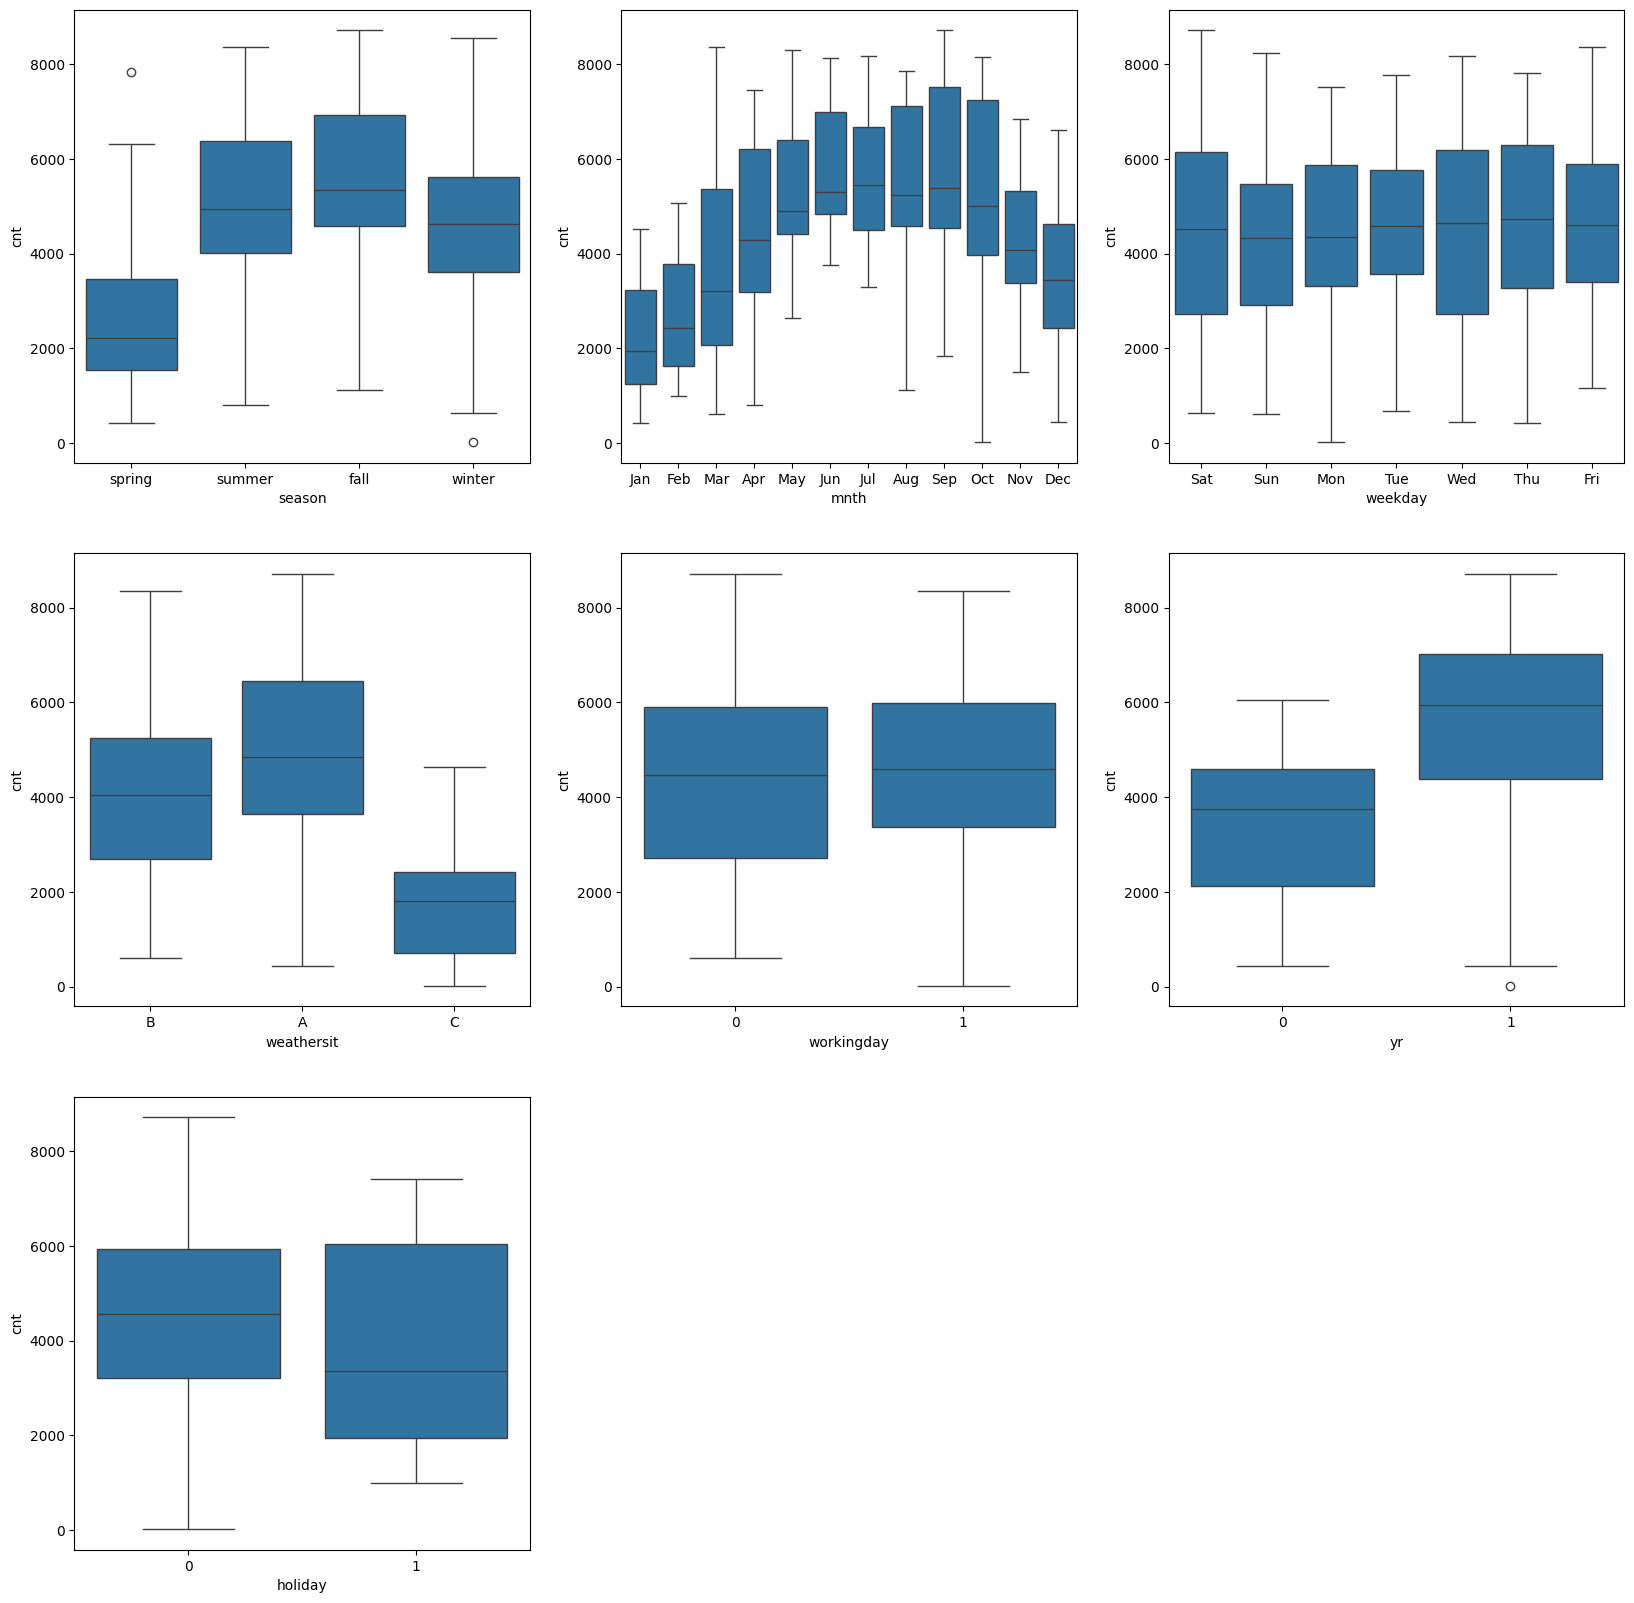

In [95]:
plt.figure(figsize=(20,20))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'cnt', data=dataset)
plt.subplot(3,3,2)
sns.boxplot(x = 'mnth', y = 'cnt', data=dataset)
plt.subplot(3,3,3)
sns.boxplot(x = 'weekday', y = 'cnt', data=dataset)
plt.subplot(3,3,4)
sns.boxplot(x = 'weathersit', y = 'cnt', data=dataset)
plt.subplot(3,3,5)
sns.boxplot(x = 'workingday', y = 'cnt', data=dataset)
plt.subplot(3,3,6)
sns.boxplot(x = 'yr', y = 'cnt', data=dataset)
plt.subplot(3,3,7)
sns.boxplot(x = 'holiday', y = 'cnt', data=dataset)
plt.show()

In [96]:
intVarlist = ["casual", "registered", "cnt"]

for var in intVarlist:
  dataset[var] = dataset[var].astype("float")

In [97]:
dataset_numeric = dataset.select_dtypes(include=['float64'])
dataset_numeric.head()

,temp,atemp,hum,windspeed,casual,registered,cnt
0,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


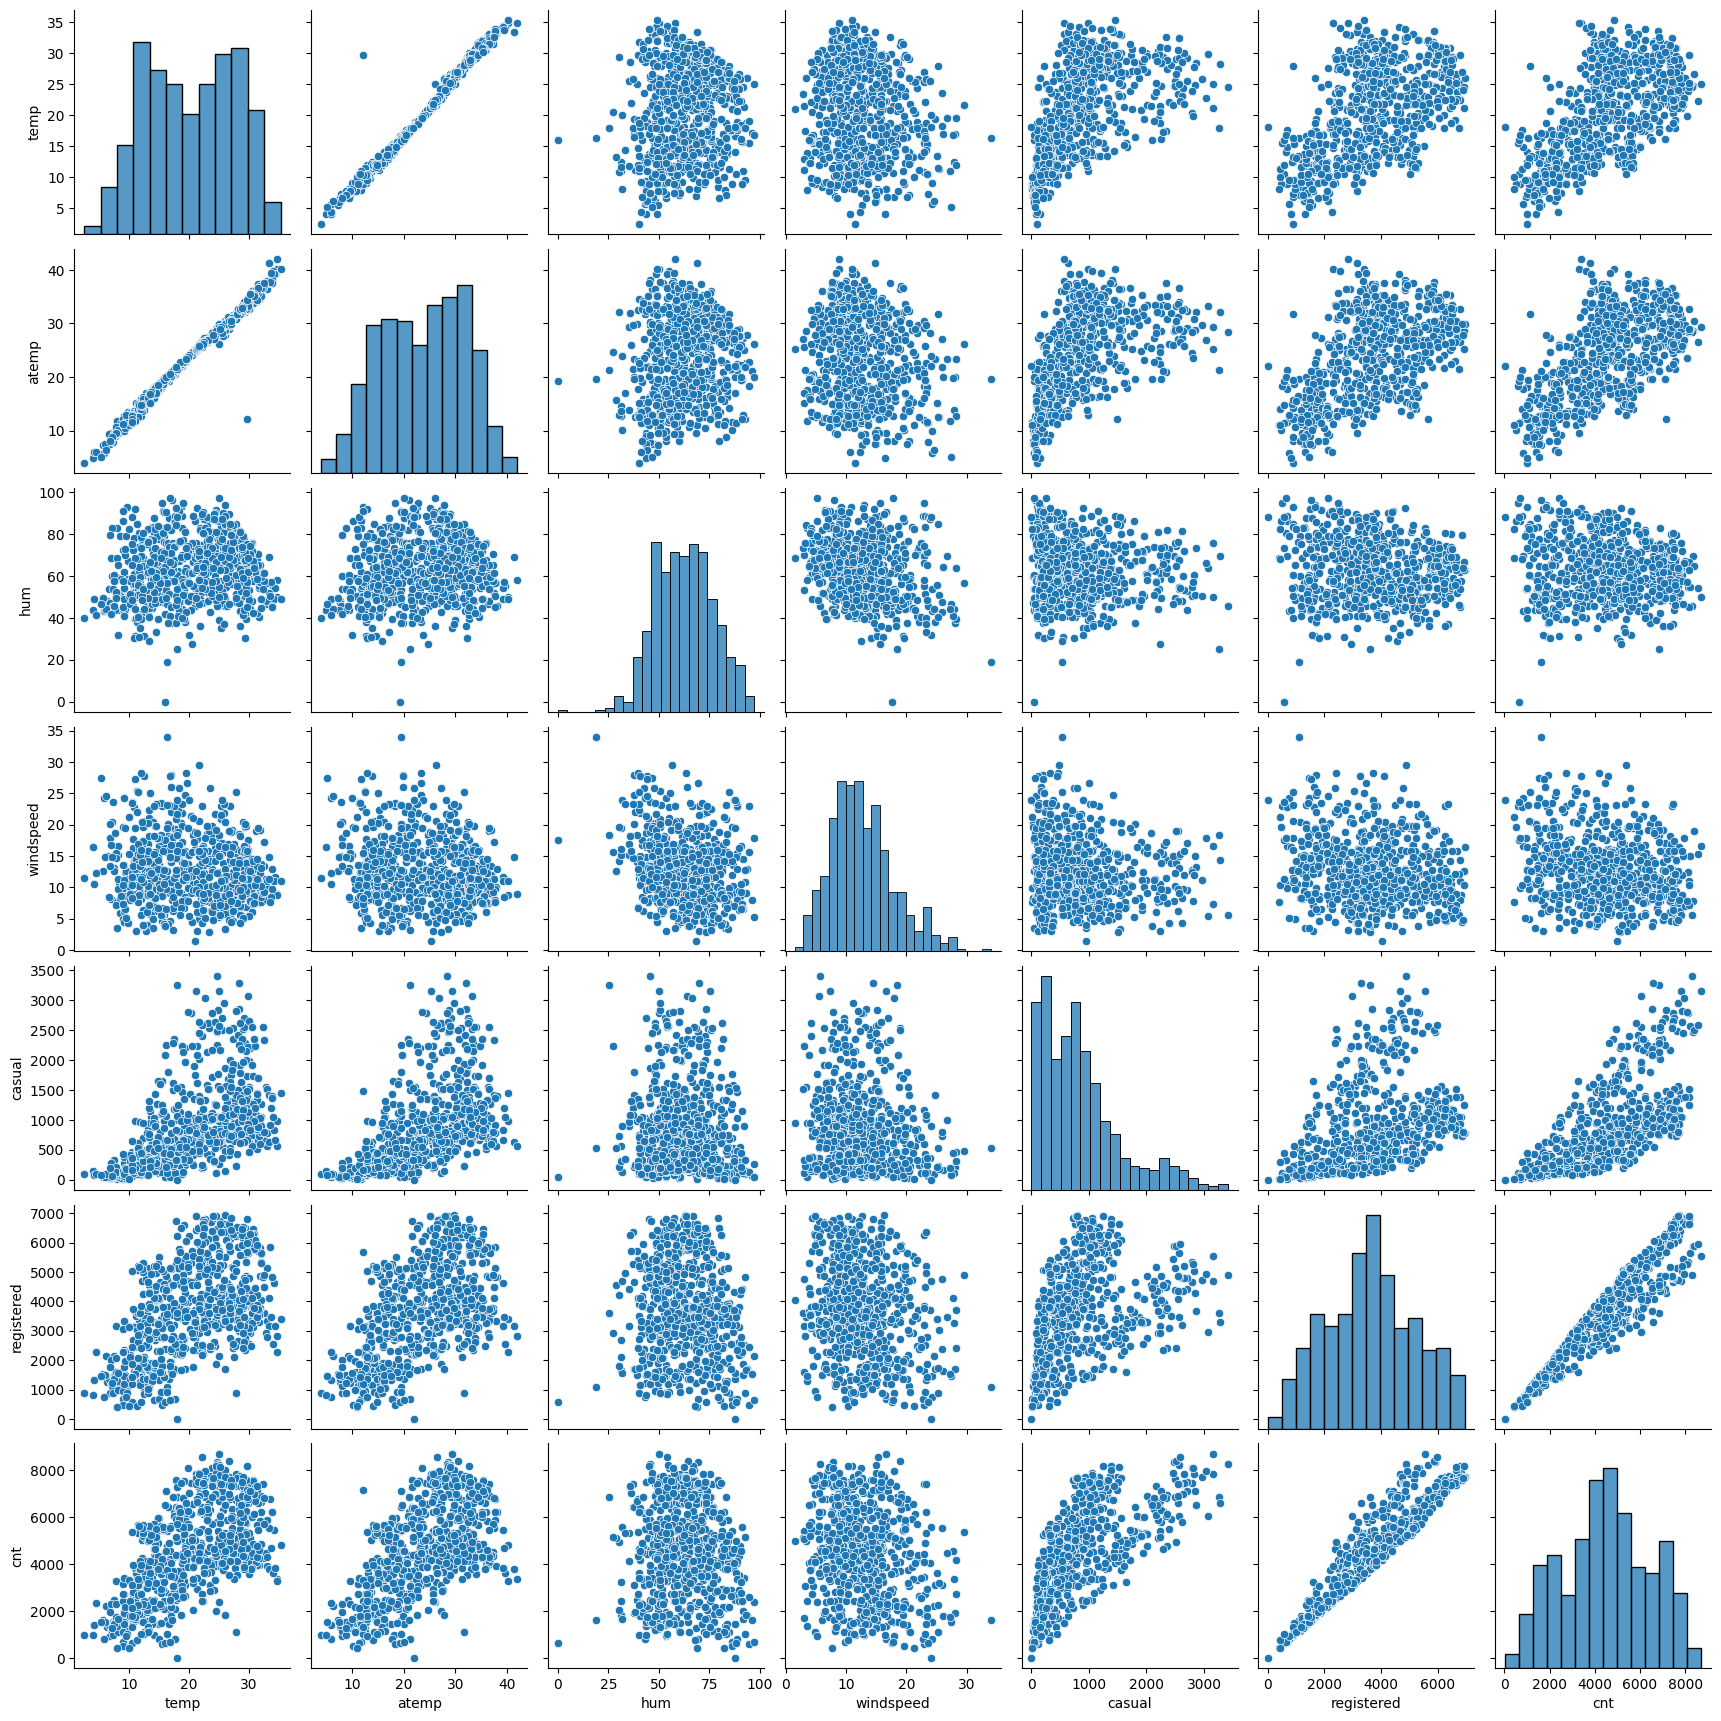

In [98]:
sns.pairplot(dataset_numeric)
plt.show()

In [99]:
cor = dataset_numeric.corr()
cor

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991696,0.128565,-0.158186,0.542731,0.539436,0.627044
atemp,0.991696,1.000000,0.141512,-0.183876,0.543362,0.543678,0.630685
hum,0.128565,0.141512,1.000000,-0.248506,-0.075211,-0.089212,-0.098543
windspeed,-0.158186,-0.183876,-0.248506,1.000000,-0.167995,-0.217914,-0.235132
casual,0.542731,0.543362,-0.075211,-0.167995,1.000000,0.394137,0.672123
registered,0.539436,0.543678,-0.089212,-0.217914,0.394137,1.000000,0.945411
cnt,0.627044,0.630685,-0.098543,-0.235132,0.672123,0.945411,1.000000


<Axes: >

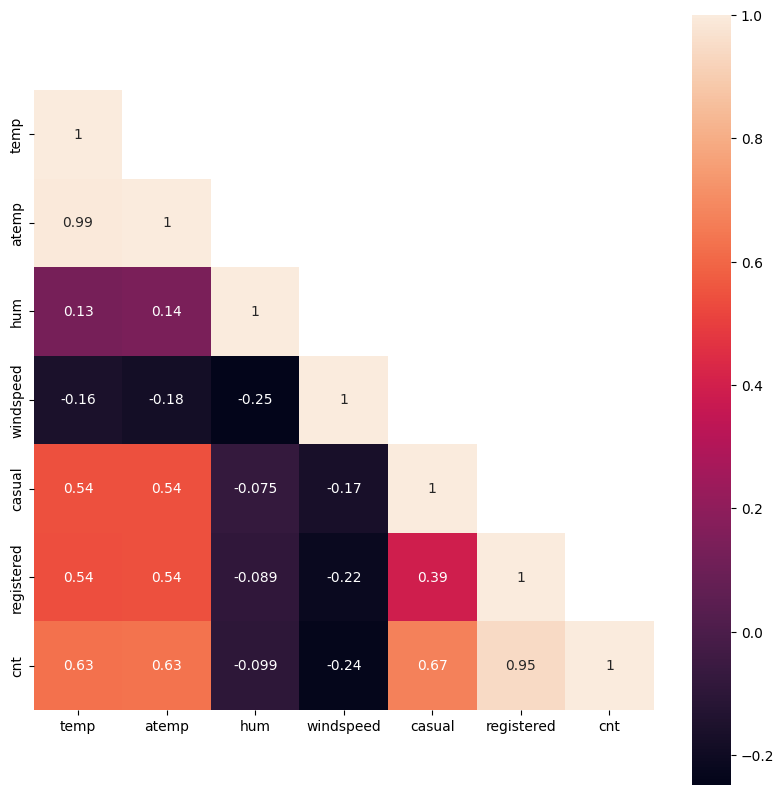

In [100]:
# heatmap

mask = np.array(cor)
mask[np.tril_indices_from(mask)] = False
fig, ax = plt.subplots()
fig.set_size_inches(10,10)
sns.heatmap(cor, mask=mask, vmax=1 , square = True, annot = True)

In [101]:
# Removing atemp as it is highly corealed with temp
dataset.drop('atemp', axis=1, inplace=True)

In [102]:
dataset

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,spring,0,Jan,0,Sat,0,B,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,spring,0,Jan,0,Sun,0,B,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,spring,0,Jan,0,Mon,1,A,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,spring,0,Jan,0,Tue,1,A,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,spring,0,Jan,0,Wed,1,A,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,spring,1,Dec,0,Thu,1,B,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,2019-12-28,spring,1,Dec,0,Fri,1,B,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,2019-12-29,spring,1,Dec,0,Sat,0,B,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,2019-12-30,spring,1,Dec,0,Sun,0,A,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


## 3. Data Preparation ##

In [103]:
dataset_categorical = dataset.select_dtypes(include=['object'])

In [104]:
dataset_categorical.head()

,season,mnth,weekday,weathersit
0,spring,Jan,Sat,B
1,spring,Jan,Sun,B
2,spring,Jan,Mon,A
3,spring,Jan,Tue,A
4,spring,Jan,Wed,A


In [105]:
dataset_dummies = pd.get_dummies(dataset_categorical, drop_first=True)
dataset_dummies.head()

,season_spring,season_summer,season_winter,mnth_Aug,mnth_Dec,mnth_Feb,mnth_Jan,mnth_Jul,mnth_Jun,mnth_Mar,...,mnth_Oct,mnth_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_B,weathersit_C
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [106]:
# Drop Categorical variable columns
dataset = dataset.drop(list(dataset_categorical.columns), axis=1)
dataset

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,1,0,1,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,2019-12-28,1,0,1,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,2019-12-29,1,0,0,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,2019-12-30,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


In [107]:
dataset = dataset.drop(['instant'], axis=1, inplace=False)
dataset.head()

,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
0,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0


## Model Building and Evaluation ##

In [108]:
# Import libs
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [109]:
# split the dataframe into train and test datasets
from sklearn.model_selection import train_test_split
np.random.seed(0)
df_train, df_test = train_test_split(dataset, train_size=0.7, test_size=0.3, random_state=100)

In [110]:
df_train

,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
653,2019-10-16,1,0,1,19.201653,55.8333,12.208807,922.0,6612.0,7534.0
576,2019-07-31,1,0,1,29.246653,70.4167,11.083475,968.0,6248.0,7216.0
426,2019-03-03,1,0,0,16.980847,62.1250,10.792293,956.0,3110.0,4066.0
728,2019-12-30,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0
482,2019-04-28,1,0,0,15.443347,48.9583,8.708325,1120.0,3100.0,4220.0
...,...,...,...,...,...,...,...,...,...,...
526,2019-11-06,1,0,1,29.554153,58.7917,13.916771,1017.0,5647.0,6664.0
578,2019-02-08,1,0,1,30.852500,65.9583,8.666718,983.0,6278.0,7261.0
53,2018-02-23,0,0,1,9.091299,42.3043,6.305571,139.0,1778.0,1917.0
350,2018-12-17,0,0,0,10.591653,56.0833,16.292189,275.0,2464.0,2739.0


In [111]:
from sklearn.preprocessing import MinMaxScaler

In [112]:
scaler = MinMaxScaler()

In [113]:
# Apply scaler to all columns except dummy variables
var = ["temp", "hum", "windspeed", "casual", "registered", "cnt"]

df_train[var] = scaler.fit_transform(df_train[var])

In [114]:
df_train.describe()

,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
count,510,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,2019-01-02 21:04:56.470588160,0.507843,0.025490,0.676471,0.537262,0.650369,0.320768,0.254661,0.523944,0.513620
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-07-01 06:00:00,0.000000,0.000000,0.000000,0.339853,0.538643,0.199179,0.094179,0.353487,0.356420
50%,2019-01-05 12:00:00,1.000000,0.000000,1.000000,0.540519,0.653714,0.296763,0.212740,0.525123,0.518638
75%,2019-07-07 18:00:00,1.000000,0.000000,1.000000,0.735215,0.754830,0.414447,0.327415,0.696073,0.684710
max,2019-12-30 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,0.500429,0.157763,0.468282,0.225844,0.145882,0.169797,0.206011,0.228175,0.224593


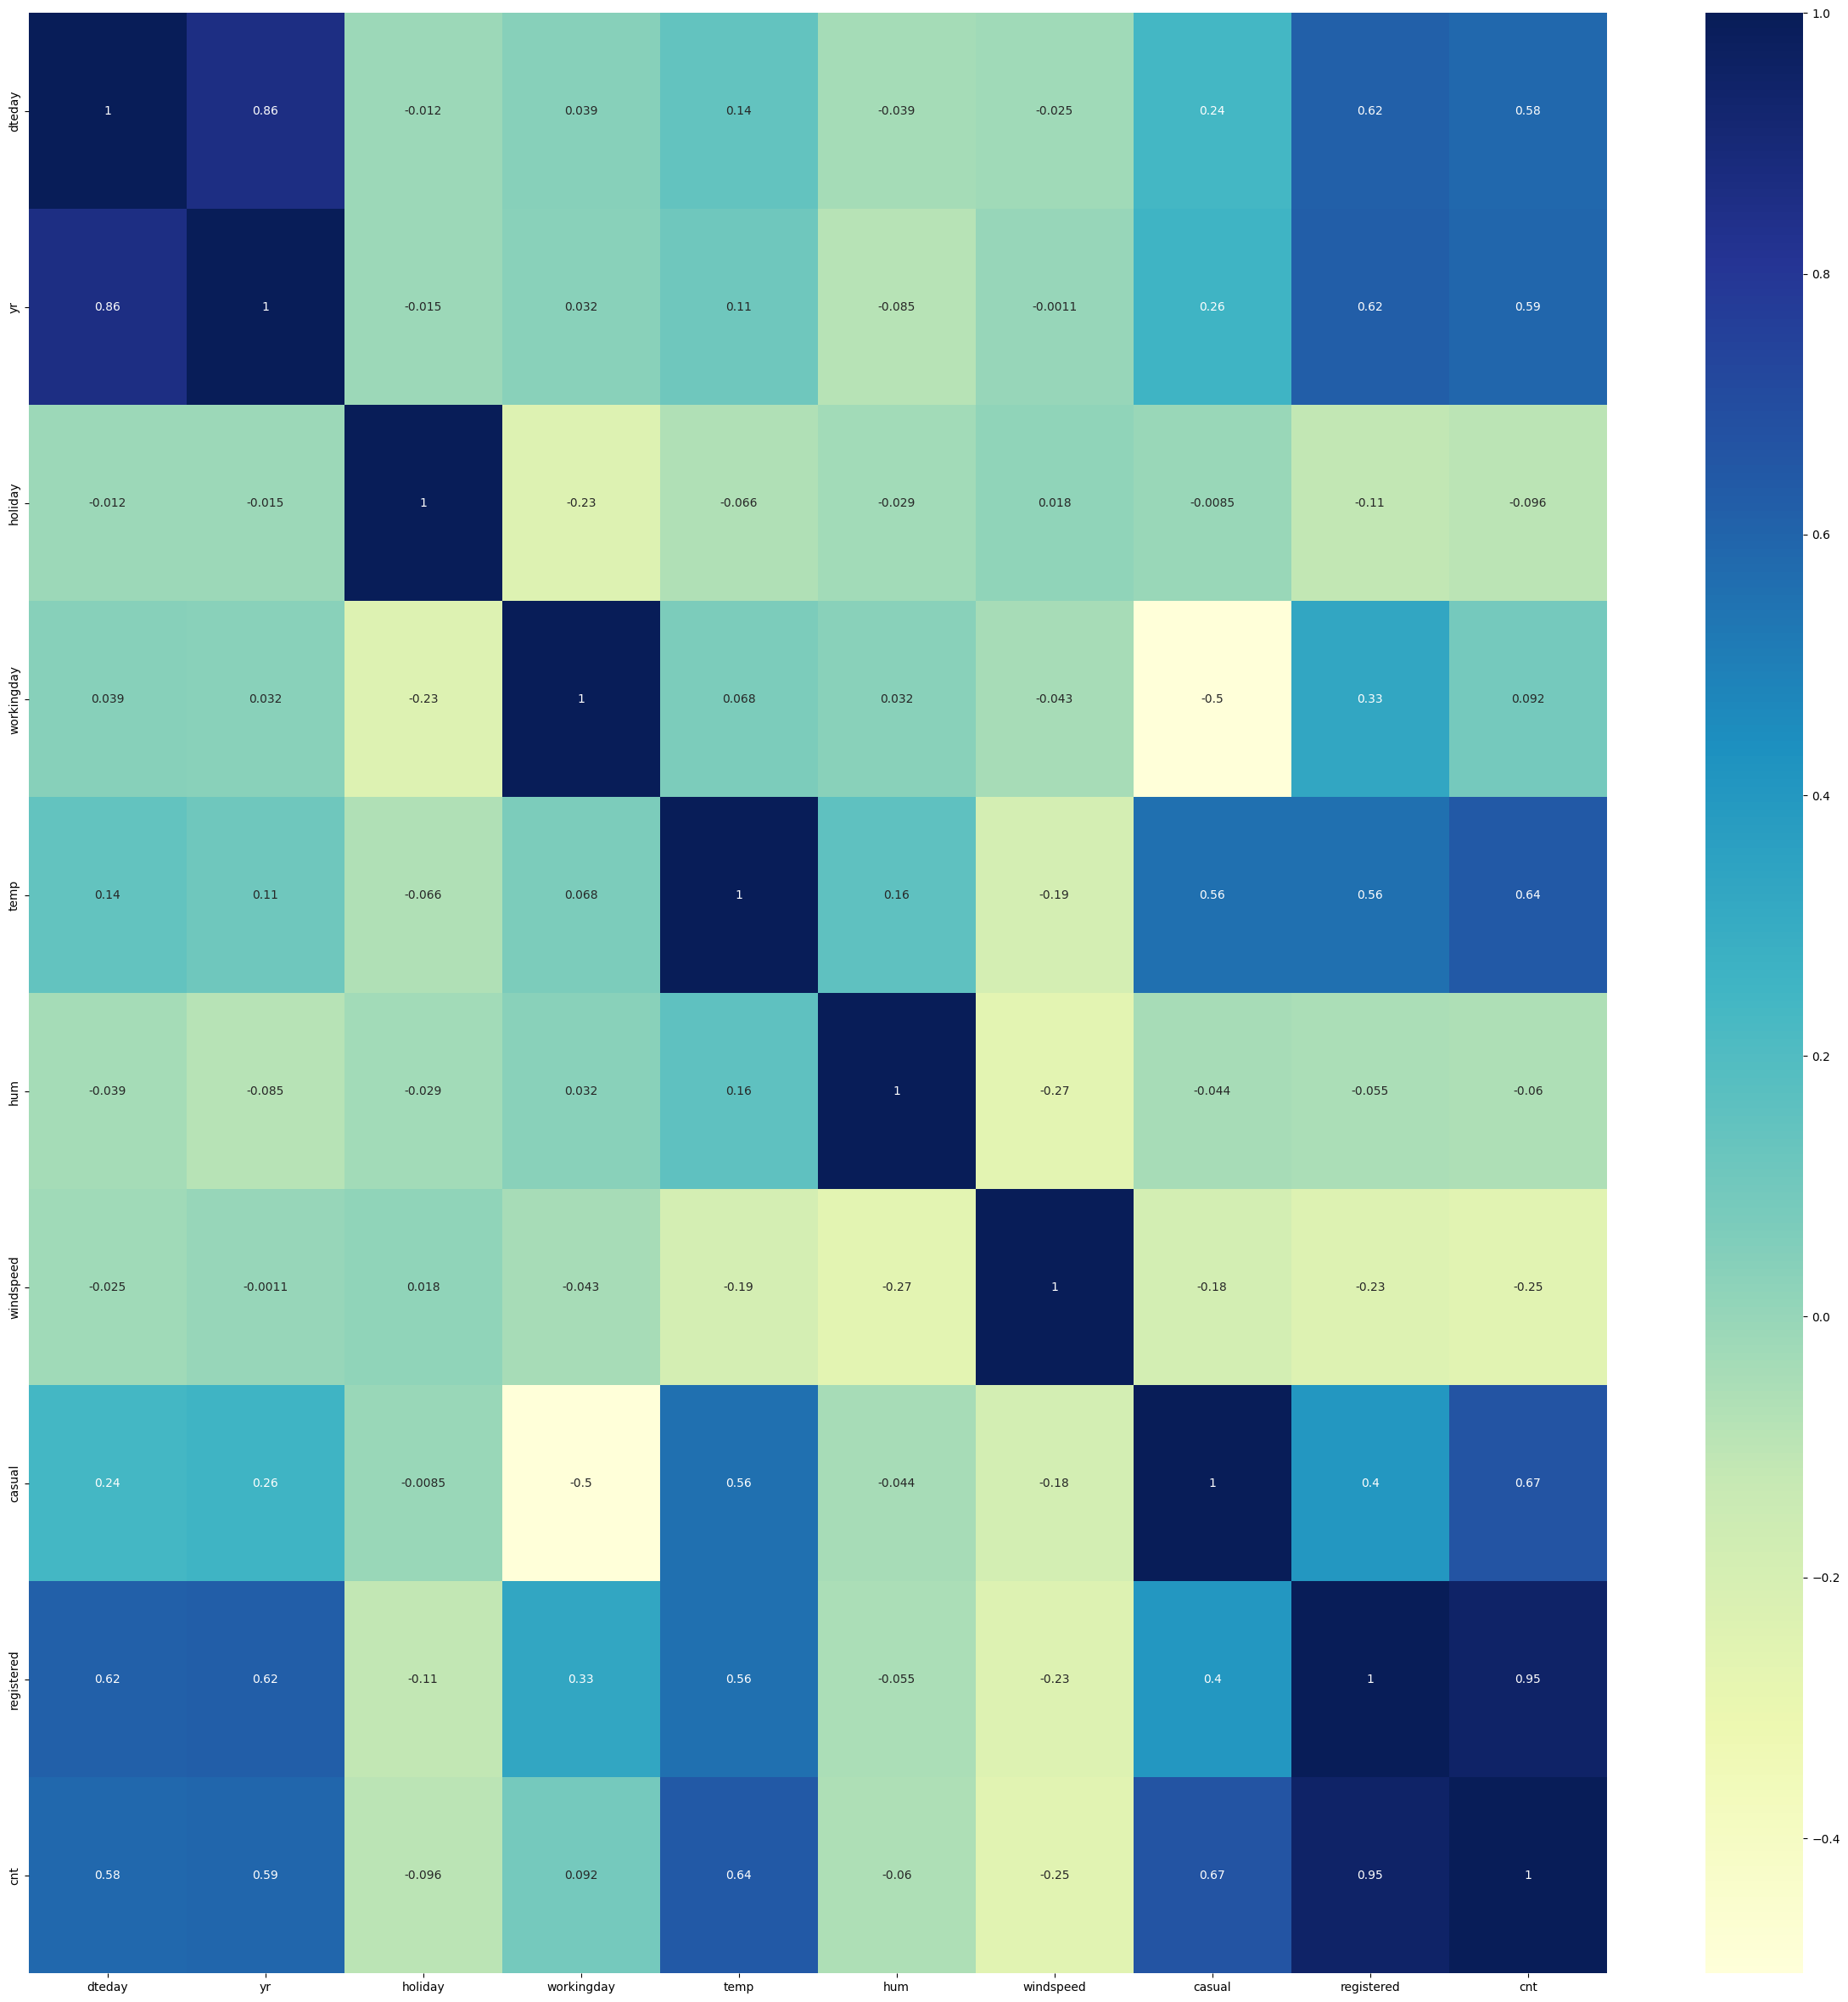

In [115]:
# Checking the coreelation to the which variable are highly corelated

plt.figure(figsize=(30,30))
sns.heatmap(df_train.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [116]:
# Dividing into x and y
y_train = df_train.pop('cnt')
x_train = df_train.drop(["casual", "registered"], axis=1)

In [117]:
x_train.head()

,dteday,yr,holiday,workingday,temp,hum,windspeed
653,2019-10-16,1,0,1,0.509887,0.575354,0.300794
576,2019-07-31,1,0,1,0.815169,0.725633,0.264686
426,2019-03-03,1,0,0,0.442393,0.640189,0.255342
728,2019-12-30,1,0,0,0.245101,0.498067,0.663106
482,2019-04-28,1,0,0,0.395666,0.504508,0.188475


In [121]:
np.asarray(df_train)

array([[Timestamp('2019-10-16 00:00:00'), 1, 0, ..., 0.3007936214471273,
        0.2804023163669613, 0.9517759168351142],
       [Timestamp('2019-07-31 00:00:00'), 1, 0, ..., 0.26468552244953764,
        0.29442243218530934, 0.8992203291943403],
       [Timestamp('2019-03-03 00:00:00'), 1, 0, ..., 0.25534247659079007,
        0.2907650106674794, 0.4461449610164598],
       ...,
       [Timestamp('2018-02-23 00:00:00'), 0, 0, ..., 0.11137873775579435,
        0.041755562328558364, 0.2538261622870344],
       [Timestamp('2018-12-17 00:00:00'), 0, 0, ..., 0.43181554342302025,
        0.08320633953063089, 0.35287323130233905],
       [Timestamp('2018-03-21 00:00:00'), 0, 0, ..., 0.5298809782809655,
        0.12160926546784516, 0.2390990470690153]], dtype=object)

In [133]:
import statsmodels.api as sm

# Drop 'dteday' column as it's a datetime object and not suitable for direct OLS input
x_train_processed = x_train.drop('dteday', axis=1)
x_train_lm = sm.add_constant(x_train_processed)

lr = sm.OLS(y_train, x_train_lm).fit()

In [128]:
x_train_lm

,const,yr,holiday,workingday,temp,hum,windspeed
653,1.0,1,0,1,0.509887,0.575354,0.300794
576,1.0,1,0,1,0.815169,0.725633,0.264686
426,1.0,1,0,0,0.442393,0.640189,0.255342
728,1.0,1,0,0,0.245101,0.498067,0.663106
482,1.0,1,0,0,0.395666,0.504508,0.188475
...,...,...,...,...,...,...,...
526,1.0,1,0,1,0.824514,0.605840,0.355596
578,1.0,1,0,1,0.863973,0.679690,0.187140
53,1.0,0,0,1,0.202618,0.435939,0.111379
350,1.0,0,0,0,0.248216,0.577930,0.431816


In [131]:
lr.params

,0
const,0.320291
yr,0.231155
holiday,-0.065641
workingday,0.011173
temp,0.570023
hum,-0.241885
windspeed,-0.245925


In [135]:
lm = LinearRegression()
# Drop 'dteday' column as it's a datetime object and not suitable for linear regression
x_train_processed_lm = x_train.drop('dteday', axis=1)
lm.fit(x_train_processed_lm, y_train)

LinearRegression()

In [137]:
print(lm.coef_)
print(lm.intercept_)

[ 0.23115477 -0.06564118  0.01117328  0.5700234  -0.24188517 -0.24592469]
0.320291386513489


In [138]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     234.6
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          3.03e-142
Time:                        08:48:17   Log-Likelihood:                 378.81
No. Observations:                 510   AIC:                            -743.6
Df Residuals:                     503   BIC:                            -714.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3203      0.032      9.905      0.000       0.257       0.384
yr             0.2312      0.010     22.254      0.000       0.211       0.252
holiday       -0.0656      0.034     -1.957      0.051      -0.132       0.000
workingday     0.0112      0.011      0.988      0.324      -0.011       0.033
temp           0.5700      0.024     24.214      0.000       0.524       0.616
hum           -0.2419      0.037     -6.541      0.000      -0.315      -0.169
windspeed     -0.2459      0.032     -7.736      0.000      -0.308      -0.183
==============================================================================
Omnibus:                       15.562   Durbin-Watson:                   2.032
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.335
Skew:                          -0.336   Prob(JB):                     0.000104
Kurtosis:                       3.641   Cond. No.                         15.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [139]:
# import rfe
from sklearn.feature_selection import RFE

In [145]:
lm = LinearRegression()
# Drop 'dteday' column from x_train for RFE as it's a datetime object
x_train_rfe = x_train.drop('dteday', axis=1)

# Correcting the RFE constructor to use keyword arguments for n_features_to_select
# and adjusting the number of features to select as 15 was too high for the available features (6).
rfe1 = RFE(estimator=lm, n_features_to_select=5)

# fit with 5 features (after dropping 'dteday')
rfe1.fit(x_train_rfe, y_train)
print(rfe1.support_)
print(rfe1.ranking_)

[ True  True False  True  True  True]
[1 1 2 1 1 1]


In [150]:
col1 = x_train_rfe.columns[rfe1.support_]

In [151]:
col1

Index(['yr', 'holiday', 'temp', 'hum', 'windspeed'], dtype='object')

In [153]:
x_train_rfe1 = x_train[col1]

x_train_rfe1 = sm.add_constant(x_train_rfe1)
lm1 = sm.OLS(y_train, x_train_rfe1).fit()
lm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     281.3
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          2.79e-143
Time:                        08:57:10   Log-Likelihood:                 378.31
No. Observations:                 510   AIC:                            -744.6
Df Residuals:                     504   BIC:                            -719.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3273      0.032     10.379      0.000       0.265       0.389
yr             0.2314      0.010     22.286      0.000       0.211       0.252
holiday       -0.0733      0.033     -2.244      0.025      -0.137      -0.009
temp           0.5710      0.024     24.279      0.000       0.525       0.617
hum           -0.2414      0.037     -6.529      0.000      -0.314      -0.169
windspeed     -0.2468      0.032     -7.766      0.000      -0.309      -0.184
==============================================================================
Omnibus:                       17.032   Durbin-Watson:                   2.028
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.733
Skew:                          -0.367   Prob(JB):                     5.19e-05
Kurtosis:                       3.625   Cond. No.                         13.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [160]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [161]:
a = x_train_rfe1.drop('const', axis=1)

In [162]:
# Evaluating VIFs
vif = pd.DataFrame()
vif['Features'] = a.columns
vif['VIF'] = [variance_inflation_factor(a.values, i) for i in range(a.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,hum,7.90
2,temp,6.31
4,windspeed,3.40
0,yr,2.00
1,holiday,1.03


In [164]:
lm = LinearRegression()
# Drop 'dteday' column from x_train for RFE as it's a datetime object
x_train_rfe2 = x_train.drop('dteday', axis=1)
rfe2 = RFE(estimator=lm, n_features_to_select=7)

#fit with 7 features
rfe2.fit(x_train_rfe2, y_train)
print(rfe2.support_)
print(rfe2.ranking_)

[ True  True  True  True  True  True]
[1 1 1 1 1 1]


In [165]:
col2 = x_train_rfe2.columns[rfe2.support_]

x_train_rfe2 = x_train[col2]

x_train_rfe2 = sm.add_constant(x_train_rfe2)
lm2 = sm.OLS(y_train, x_train_rfe2).fit()
lm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     234.6
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          3.03e-142
Time:                        09:06:03   Log-Likelihood:                 378.81
No. Observations:                 510   AIC:                            -743.6
Df Residuals:                     503   BIC:                            -714.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3203      0.032      9.905      0.000       0.257       0.384
yr             0.2312      0.010     22.254      0.000       0.211       0.252
holiday       -0.0656      0.034     -1.957      0.051      -0.132       0.000
workingday     0.0112      0.011      0.988      0.324      -0.011       0.033
temp           0.5700      0.024     24.214      0.000       0.524       0.616
hum           -0.2419      0.037     -6.541      0.000      -0.315      -0.169
windspeed     -0.2459      0.032     -7.736      0.000      -0.308      -0.183
==============================================================================
Omnibus:                       15.562   Durbin-Watson:                   2.032
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.335
Skew:                          -0.336   Prob(JB):                     0.000104
Kurtosis:                       3.641   Cond. No.                         15.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [166]:
# Evaluating VIFs
b = x_train_rfe2.drop('const', axis=1)
vif1 = pd.DataFrame()
vif1['Features'] = b.columns
vif1['VIF'] = [variance_inflation_factor(b.values, i) for i in range(b.shape[1])]
vif1['VIF'] = round(vif1['VIF'], 2)
vif1 = vif1.sort_values(by = "VIF", ascending = False)
vif1

,Features,VIF
4,hum,8.75
3,temp,6.40
5,windspeed,3.45
2,workingday,3.12
0,yr,2.01
1,holiday,1.07


In [167]:
y_train_cnt = lm2.predict(x_train_rfe2)

Text(0.5, 0, 'Errors')

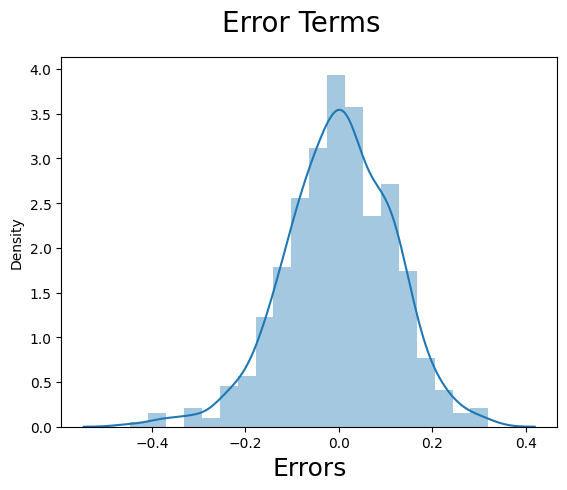

In [168]:
fig = plt.figure()
sns.distplot((y_train - y_train_cnt), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading
plt.xlabel('Errors', fontsize = 18)

In [169]:
df_test[var] = scaler.transform(df_test[var])
df_test

,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
184,2018-04-07,0,1,0,0.831783,0.657364,0.084219,0.933557,0.427086,0.692706
535,2019-06-20,1,0,1,0.901354,0.610133,0.153728,0.265163,0.767976,0.712034
299,2018-10-27,0,0,1,0.511964,0.837699,0.334206,0.072539,0.346376,0.303382
221,2018-10-08,0,0,1,0.881625,0.437098,0.339570,0.268820,0.559630,0.547400
152,2018-02-06,0,0,1,0.817246,0.314298,0.537414,0.223712,0.608143,0.569029
...,...,...,...,...,...,...,...,...,...,...
400,2019-05-02,1,0,0,0.257562,0.708888,0.287411,0.096312,0.376697,0.336516
702,2019-04-12,1,0,1,0.519232,0.756118,0.283397,0.167327,0.871354,0.757478
127,2018-08-05,0,0,0,0.584649,0.650923,0.069510,0.426394,0.420445,0.495973
640,2019-03-10,1,0,1,0.745598,0.817947,0.052115,0.221274,0.985273,0.868615


In [170]:
y_test = df_test.pop('cnt')
x_test = df_test.drop(['casual','registered'],axis=1)

In [171]:
x_test.head()

,dteday,yr,holiday,workingday,temp,hum,windspeed
184,2018-04-07,0,1,0,0.831783,0.657364,0.084219
535,2019-06-20,1,0,1,0.901354,0.610133,0.153728
299,2018-10-27,0,0,1,0.511964,0.837699,0.334206
221,2018-10-08,0,0,1,0.881625,0.437098,0.339570
152,2018-02-06,0,0,1,0.817246,0.314298,0.537414


In [172]:
c = x_train_rfe2.drop('const', axis=1)

In [173]:
col2 = c.columns

In [174]:
x_test_rfe2 = x_test[col2]

In [179]:
x_test_rfe2 = sm.add_constant(x_test_rfe2)

In [180]:
x_test_rfe2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 184 to 72
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   const       219 non-null    float64
 1   yr          219 non-null    int64  
 2   holiday     219 non-null    int64  
 3   workingday  219 non-null    int64  
 4   temp        219 non-null    float64
 5   hum         219 non-null    float64
 6   windspeed   219 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 13.7 KB


In [181]:
y_pred = lm2.predict(x_test_rfe2)

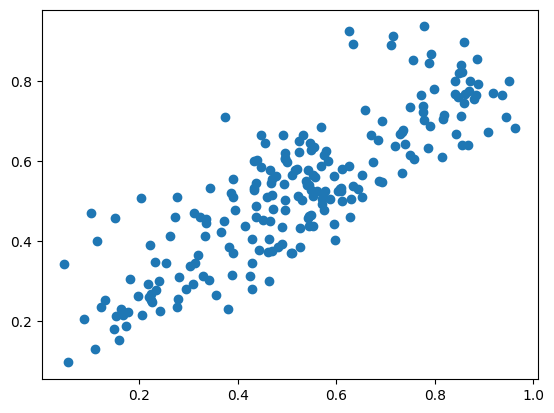

In [182]:
plt.figure()
plt.scatter(y_test, y_pred)

In [183]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.712212694112065

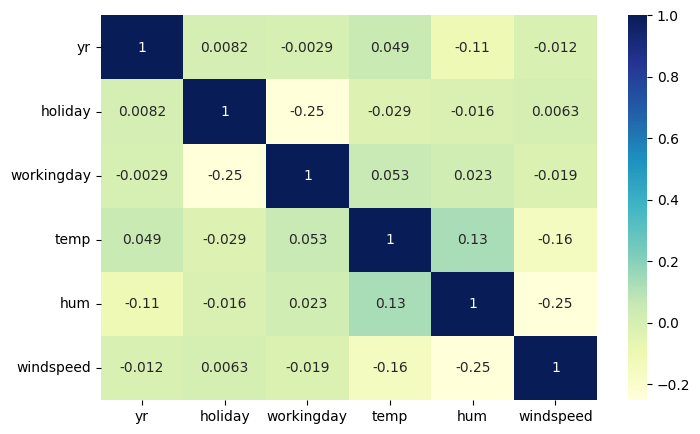

In [185]:
plt.figure(figsize=(8,5))

sns.heatmap(dataset[col2].corr(), cmap = "YlGnBu", annot = True)
plt.show()